# Домашнее задание "NLP. Часть 1"

In [1]:
import math
import re
import os
import random
from collections import Counter
from typing import List, Dict, Tuple, Any
import matplotlib.pyplot as plt

import torch
import numpy as np
import datasets
import fasttext
import fasttext.util
from transformers import BertTokenizer, BertModel

In [3]:
def seed_everything(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed_everything(42)

In [2]:
def normalize_pretokenize_text(text: str) -> List[str]:
    text = text.lower()
    words = re.findall(r'\b\w+\b', text)
    return words


In [4]:
# This block is for tests only
test_corpus = [
    "the quick brown fox jumps over the lazy dog",
    "never jump over the lazy dog quickly",
    "brown foxes are quick and dogs are lazy"
]

def build_vocab(texts: List[str]) -> Tuple[List[str], Dict[str, int]]:
    all_words = []
    for text in texts:
        words = normalize_pretokenize_text(text)
        all_words.extend(words)
    vocab = sorted(set(all_words))
    vocab_index = {word: idx for idx, word in enumerate(vocab)}
    return vocab, vocab_index

vocab, vocab_index = build_vocab(test_corpus)
print(vocab, vocab_index)

['and', 'are', 'brown', 'dog', 'dogs', 'fox', 'foxes', 'jump', 'jumps', 'lazy', 'never', 'over', 'quick', 'quickly', 'the'] {'and': 0, 'are': 1, 'brown': 2, 'dog': 3, 'dogs': 4, 'fox': 5, 'foxes': 6, 'jump': 7, 'jumps': 8, 'lazy': 9, 'never': 10, 'over': 11, 'quick': 12, 'quickly': 13, 'the': 14}


## Задание 1 (0.5 балла)
Реализовать One-Hot векторизацию текстов

In [5]:
def one_hot_vectorization(text: str, vocab: List[str] = None, vocab_index: Dict[str, int] = None) -> List[int]:
    text_prepr = normalize_pretokenize_text(text)
    return [1 if token in text_prepr else 0 for token in vocab]

def test_one_hot_vectorization(corpus, vocab, vocab_index) -> bool:
    try:
        text = "the quick brown fox"
        result = one_hot_vectorization(text, vocab, vocab_index)

        if not isinstance(result, list):
            return False

        expected_length = len(vocab)
        if len(result) != expected_length:
            return False

        words_in_text = normalize_pretokenize_text(text)
        for word in words_in_text:
            if word in vocab_index:
                idx = vocab_index[word]
                if result[idx] != 1:
                    return False

        print("One-Hot-Vectors test PASSED")

        return True
    except Exception as e:
        print(f"One-Hot-Vectors test FAILED: {e}")
        return False

In [6]:
assert test_one_hot_vectorization(test_corpus, vocab, vocab_index)

One-Hot-Vectors test PASSED


## Задание 2 (0.5 балла)
Реализовать Bag-of-Words

In [7]:
def bag_of_words_vectorization(text: str) -> Dict[str, int]:
    text_prepr = normalize_pretokenize_text(text)
    return dict(Counter(text_prepr))

def test_bag_of_words_vectorization() -> bool:
    try:
        text = "the the quick brown brown brown"
        result = bag_of_words_vectorization(text)

        if not isinstance(result, dict):
            return False

        if result.get('the', 0) != 2:
            return False
        if result.get('quick', 0) != 1:
            return False
        if result.get('brown', 0) != 3:
            return False
        if result.get('nonexistent', 0) != 0:
            return False

        print("Bag-of-Words test PASSED")
        return True
    except Exception as e:
        print(f"Bag-of-Words test FAILED: {e}")
        return False

In [8]:
assert test_bag_of_words_vectorization()

Bag-of-Words test PASSED


## Задание 3 (0.5 балла)
Реализовать TF-IDF

In [9]:
def tf_idf_vectorization(text: str, corpus: List[str] = None, vocab: List[str] = None, vocab_index: Dict[str, int] = None) -> List[float]:
    text_prepr = normalize_pretokenize_text(text)
    words_count = Counter(text_prepr)
    text_len = len(text_prepr)
    tfs = [words_count[word] / text_len for word in vocab]
    corpus_len = len(corpus)
    idfs = []
    corpus_prepr = [normalize_pretokenize_text(doc) for doc in corpus]
    for word in vocab:
        word_occurs = sum(1 for doc in corpus_prepr if word in doc)
        idf = math.log2((1 + corpus_len) / (1 + word_occurs))
        idfs.append(idf)
    tf_idf = [tf*idf for tf, idf in zip(tfs, idfs)]
    return tf_idf

def test_tf_idf_vectorization(corpus, vocab, vocab_index) -> bool:
    try:
        text = "the quick brown"
        result = tf_idf_vectorization(text, corpus, vocab, vocab_index)

        if not isinstance(result, list):
            return False

        expected_length = len(vocab)
        if len(result) != expected_length:
            return False

        for val in result:
            if not isinstance(val, float):
                return False

        print("TF-IDF test PASSED")
        return True
    except Exception as e:
        print(f"TF-IDF test FAILED: {e}")
        return False

In [10]:
assert test_tf_idf_vectorization(test_corpus, vocab, vocab_index)

TF-IDF test PASSED


## Задание 4 (1 балл)
Реализовать Positive Pointwise Mutual Information (PPMI).  
https://en.wikipedia.org/wiki/Pointwise_mutual_information
$$PPMI(word, context) = max(0, PMI(word, context))$$
$$PMI(word, context) = log \frac{P(word, context)}{P(word) P(context)} = log \frac{N(word, context)|(word, context)|}{N(word) N(context)}$$
где $N(word, context)$ -- число вхождений слова $word$ в окно $context$ (размер окна -- гиперпараметр)

In [11]:
def ppmi_vectorization(
    text: str,
    corpus: List[str] = None,
    vocab: List[str] = None,
    vocab_index: Dict[str, int] = None,
    window_size: int = 1
) -> List[float]:
    text_prepr = normalize_pretokenize_text(text)
    corpus_prepr = [normalize_pretokenize_text(doc) for doc in corpus]
    pairs_count = Counter()
    w_count = Counter()
    for doc_prepr in corpus_prepr:
        for word in doc_prepr:
            w_count[word] += 1

        for i, context in enumerate(doc_prepr):
            for word in doc_prepr[max(0, i-window_size): min(len(doc_prepr), i+window_size) + 1]:
                if context == word:
                    continue
                p = tuple(sorted((word, context)))
                pairs_count[p] += 1

    m_words = sum(w_count.values())
    n_pairs = sum(pairs_count.values())
    ppmi = np.zeros(shape=(len(vocab), len(vocab)))
    for pair, count in pairs_count.items():
        word, context = pair
        p_wc = count / n_pairs
        p_w = w_count[word] / m_words
        p_c = w_count[context] / m_words
        pmi = math.log2(p_wc / (p_w * p_c))
        ppmi_val = max(0, pmi)
        ppmi[vocab_index[word], vocab_index[context]] = ppmi_val
        ppmi[vocab_index[context], vocab_index[word]] = ppmi_val


    res = sum(ppmi[vocab_index[word]] if word in vocab_index.keys() else np.zeros(len(vocab)) for word in text_prepr) / len(text_prepr)

    return res.tolist()
print(ppmi_vectorization("tha rast arst fox", test_corpus, vocab, vocab_index))
print(ppmi_vectorization("tha rast arst arh", test_corpus, vocab, vocab_index))

[0.0, 0.0, 0.944401894665888, 0.0, 0.0, 0.0, 0.0, 0.0, 1.194401894665888, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [12]:
def test_ppmi_vectorization(corpus, vocab, vocab_index) -> bool:
    try:
        text = "quick brown fox"
        result = ppmi_vectorization(text, corpus, vocab, vocab_index)

        if not isinstance(result, list):
            return False

        expected_length = len(vocab)
        if len(result) != expected_length:
            return False

        for val in result:
            if not isinstance(val, float):
                return False

        print("PPMI test PASSED")
        return True
    except Exception as e:
        print(f"PPMI test FAILED: {e}")
        return False

In [13]:
assert test_ppmi_vectorization(test_corpus, vocab, vocab_index)

PPMI test PASSED


## Задание 5 (1 балл)
Реализовать получение эмбеддингов из fasttext и bert (для bert лучше использовать CLS токен)

In [14]:
def get_fasttext_embeddings(text: str, model_path: str = "imdb_fasttext_model.bin", model: any = None) -> List[np.ndarray]:
    model = model if model is not None else fasttext.load_model(model_path)
    text_prepr = normalize_pretokenize_text(text)
    embeddings = [model.get_word_vector(word) for word in text_prepr if word]
    return embeddings

fasttext model training

In [ ]:
dataset = datasets.load_dataset('imdb', split='train')
train_file_path = 'imdb_train_fasttext.txt'
with open(train_file_path, 'w', encoding='utf-8') as f:
    for item in dataset:
        text = item['text'].lower().replace('\n', ' ')
        text = re.sub(r'<br />', ' ', text)
        f.write(text + "\n")

model = fasttext.train_unsupervised(
    train_file_path,
    model='skipgram',
    dim=100,
    epoch=5,
    minCount=5
)

model_path = "imdb_fasttext_model.bin"
model.save_model(model_path)

In [ ]:
#fasttext.util.download_model('en', if_exists='ignore') тяжелая

In [15]:
ft_model = fasttext.load_model('imdb_fasttext_model.bin')
print(get_fasttext_embeddings("movie", model=ft_model))


[array([ 7.40284324e-02,  2.25248471e-01,  3.33613157e-02,  1.71778113e-01,
        4.33431596e-01,  1.23496637e-01, -2.64373720e-01, -6.05900943e-01,
       -1.94811389e-01,  2.75474191e-01, -3.29839401e-02, -7.67970458e-02,
        4.05856103e-01,  2.54593641e-01,  2.02798888e-01,  3.57420295e-02,
       -2.59755235e-02,  1.11173898e-01,  3.45765531e-01,  1.00812577e-01,
       -1.21258929e-01, -5.98043129e-02,  2.25091912e-02, -2.53196180e-01,
        1.45731613e-01, -2.92226046e-01,  1.83686078e-01, -7.32137216e-03,
       -6.01088069e-02,  2.80703872e-01,  1.55112356e-01, -2.77704775e-01,
        4.22444463e-01, -2.13293314e-01, -1.50005564e-01, -3.28744273e-03,
        1.66077018e-01, -4.42855358e-02,  4.76433724e-01,  2.65267193e-01,
        2.63554212e-02,  6.21876836e-01, -2.76095539e-01, -8.14745650e-02,
        2.35400766e-01, -1.66832060e-01,  2.57996656e-02,  1.84501052e-01,
       -1.00936495e-01,  3.57977636e-02, -4.13343072e-01,  3.59311044e-01,
        4.39009428e-01, 

In [15]:
def get_bert_embeddings(
    text: str,
    model: any = None,
    tokenizer: any = None,
    model_name: str = 'bert-base-uncased',
) -> np.ndarray:
    tokenizer = BertTokenizer.from_pretrained(model_name) if tokenizer is None else tokenizer
    model = BertModel.from_pretrained(model_name) if model is None else model
    encode = tokenizer(text, padding=True, truncation=True, return_tensors='pt')
    with torch.no_grad():
        model_output = model(**encode)
    last_hidden_states = model_output.last_hidden_state

    sentence_embedding = last_hidden_states[:, 0, :]

    return sentence_embedding.cpu().numpy().squeeze()

In [21]:
get_bert_embeddings('fox fox fox')

array([-7.19973296e-02, -5.57933077e-02, -1.31992087e-01, -2.43165158e-02,
       -3.18967998e-01, -2.17427596e-01,  6.76543891e-01,  5.77583373e-01,
       -2.27958098e-01, -2.72708267e-01, -1.00772595e-02, -1.50376812e-01,
       -2.75704619e-02,  5.79074621e-01, -8.25071707e-02,  3.09872590e-02,
       -3.80225599e-01,  7.26380467e-01,  6.80108368e-02, -3.27755749e-01,
       -1.14017867e-01, -6.62702143e-01, -2.61708945e-01,  3.14824171e-02,
        2.69370705e-01,  3.23388986e-02, -1.63354367e-01, -1.83812246e-01,
        2.95964718e-01, -1.82406172e-01,  2.07126096e-01,  1.31073281e-01,
       -2.60079890e-01, -9.93222222e-02,  1.40629923e-02, -2.03413423e-02,
        2.88311727e-02, -5.29869571e-02, -1.14663951e-01,  7.60736838e-02,
       -1.51794087e-02, -1.19467609e-01,  1.32333696e-01, -7.74948075e-02,
       -2.47317497e-02, -3.01566750e-01, -2.47801161e+00,  2.16855742e-02,
       -4.02641267e-01,  4.71113846e-02,  4.72917080e-01,  1.75900489e-01,
        6.21389329e-01,  

## Задание 6 (1.5 балла)
Реализовать обучение так, чтобы можно было поверх эмбеддингов, реализованных в предыдущих заданиях, обучить какую-то модель (вероятно неглубокую, например, CatBoost) на задаче классификации текстов ([IMDB](https://huggingface.co/datasets/stanfordnlp/imdb)).

In [16]:
def vectorize_dataset(
    dataset_name: str = "imdb",
    vectorizer_type: str = "bow",
    split: str = "train",
    sample_size: int = 2500,
    vocab_tuple: Tuple[List[str], Dict[str, int]] = None,
    train_corpus: List[str] = None,
    ft_model: any = None,
    bert_model: any = None,
    bert_tokenizer: any = None
) -> Tuple[Any, List, List, List]:

    dataset = datasets.load_dataset(dataset_name, split=split).shuffle(seed=42)
    print("dataset loaded")
    if sample_size:
        dataset = dataset.select(range(min(sample_size, len(dataset))))

    texts = [item['text'] for item in dataset if 'text' in item and item['text'].strip()]
    labels = [item['label'] for item in dataset if 'label' in item]
    if vocab_tuple:
        vocab, vocab_index = vocab_tuple
    else:
        def build_vocab(texts: List[str]) -> Tuple[List[str], Dict[str, int]]:
            all_words = []
            for text in texts:
                words = normalize_pretokenize_text(text)
                all_words.extend(words)
            vocab = sorted(set(all_words))
            vocab_index = {word: idx for idx, word in enumerate(vocab)}
            return vocab, vocab_index

        vocab, vocab_index = build_vocab(texts)
    vectorized_data = []
    if train_corpus is None:
        train_corpus = texts
    print("start vectorizing")
    for text in texts:
        if vectorizer_type == "one_hot":
            vectorized_data.append(one_hot_vectorization(text, vocab, vocab_index))
        elif vectorizer_type == "bow":
            bow_dict = bag_of_words_vectorization(text)
            vector = [bow_dict.get(word, 0) for word in vocab]
            vectorized_data.append(vector)
        elif vectorizer_type == "tfidf":
            vectorized_data.append(tf_idf_vectorization(text, train_corpus, vocab, vocab_index))
        elif vectorizer_type == "ppmi":
            vectorized_data.append(ppmi_vectorization(text, train_corpus, vocab, vocab_index))
        elif vectorizer_type == "fasttext":
            embeddings = get_fasttext_embeddings(text, model=ft_model)
            if embeddings:
                avg_embedding = np.mean(embeddings, axis=0)
                vectorized_data.append(avg_embedding.tolist())
            else:
                vectorized_data.append([0] * ft_model.get_dimension())
        elif vectorizer_type == "bert":
            embedding = get_bert_embeddings(text, model=bert_model, tokenizer=bert_tokenizer)
            vectorized_data.append(embedding.tolist())
        else:
            raise ValueError(f"Unknown vectorizer type: {vectorizer_type}")
    print("vectorized data")
    return (vocab, vocab_index), vectorized_data, labels, train_corpus

In [17]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, KFold

def train(
    embeddings_method="bow",
    cv_folds=3,
    val_size=0.2,
    sample_size=1000,
):
    ft_model = None
    bert_model, bert_tokenizer = None, None
    if embeddings_method == "fasttext":
        ft_model = fasttext.load_model('imdb_fasttext_model.bin')
    elif embeddings_method == "bert":
        bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        bert_model = BertModel.from_pretrained('bert-base-uncased')

    vocab_tuple, X, Y, train_texts = vectorize_dataset(
        "imdb", embeddings_method, "train",
        ft_model=ft_model, bert_model=bert_model, bert_tokenizer=bert_tokenizer, sample_size=sample_size
    )

    model = CatBoostClassifier(
        iterations=250,
        learning_rate=0.1,
        verbose=125,
        random_seed=42,
    )
    cv_scores = None
    if cv_folds > 1:
        print("CV Folds:", cv_folds)
        scorer = make_scorer(f1_score, average='macro')
        cv_scores = cross_val_score(model, X, Y, cv=cv_folds, scoring=scorer)
        model.set_params(verbose=0)
        print(f"CV F1 scores: {cv_scores}")
        print(f"Mean CV F1 score: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
        model.fit(X, Y)
    else:
        X_train, X_val, y_train, y_val = train_test_split(
            X, Y, test_size=val_size, random_state=42, stratify=Y)
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val)
        )

    _, X_test, y_test, _ = vectorize_dataset(
        "imdb", embeddings_method, "test", vocab_tuple=vocab_tuple, train_corpus=train_texts,
        ft_model=ft_model, bert_model=bert_model, bert_tokenizer=bert_tokenizer, sample_size=sample_size
    )

    y_pred = model.predict(X_test)
    print(f"Results for {embeddings_method}:")
    acc, f1 = accuracy_score(y_test, y_pred), f1_score(y_test, y_pred, average='macro')
    print(f"Accuracy: {acc}")
    print(f"F1 Score (macro): {f1}")
    print("-" * 50)

    return model, (acc, f1), cv_scores

In [18]:
results = []
for embeddings_method in ["bow", "one_hot", "tfidf", "ppmi", "fasttext", "bert"]:
    print(f"\n\n-----{embeddings_method}-----\n\n")
    _, metrics, cv = train(embeddings_method=embeddings_method, sample_size=100)
    results.append((embeddings_method, metrics, cv))



-----bow-----


dataset loaded
start vectorizing
vectorized data
CV Folds: 3
0:	learn: 0.6685205	total: 51.5ms	remaining: 12.8s
125:	learn: 0.0119089	total: 709ms	remaining: 698ms
249:	learn: 0.0048088	total: 1.31s	remaining: 0us
0:	learn: 0.6726773	total: 5.97ms	remaining: 1.49s
125:	learn: 0.0111311	total: 666ms	remaining: 656ms
249:	learn: 0.0041170	total: 1.29s	remaining: 0us
0:	learn: 0.6749450	total: 6.35ms	remaining: 1.58s
125:	learn: 0.0111818	total: 628ms	remaining: 618ms
249:	learn: 0.0042338	total: 1.24s	remaining: 0us
CV F1 scores: [0.66214995 0.60606061 0.60460829]
Mean CV F1 score: 0.6243 (+/- 0.0268)
dataset loaded
start vectorizing
vectorized data
Results for bow:
Accuracy: 0.64
F1 Score (macro): 0.6376811594202898
--------------------------------------------------


-----one_hot-----


dataset loaded
start vectorizing
vectorized data
CV Folds: 3
0:	learn: 0.6766474	total: 5.92ms	remaining: 1.48s
125:	learn: 0.0120585	total: 706ms	remaining: 695ms
249:	learn: 0.004401

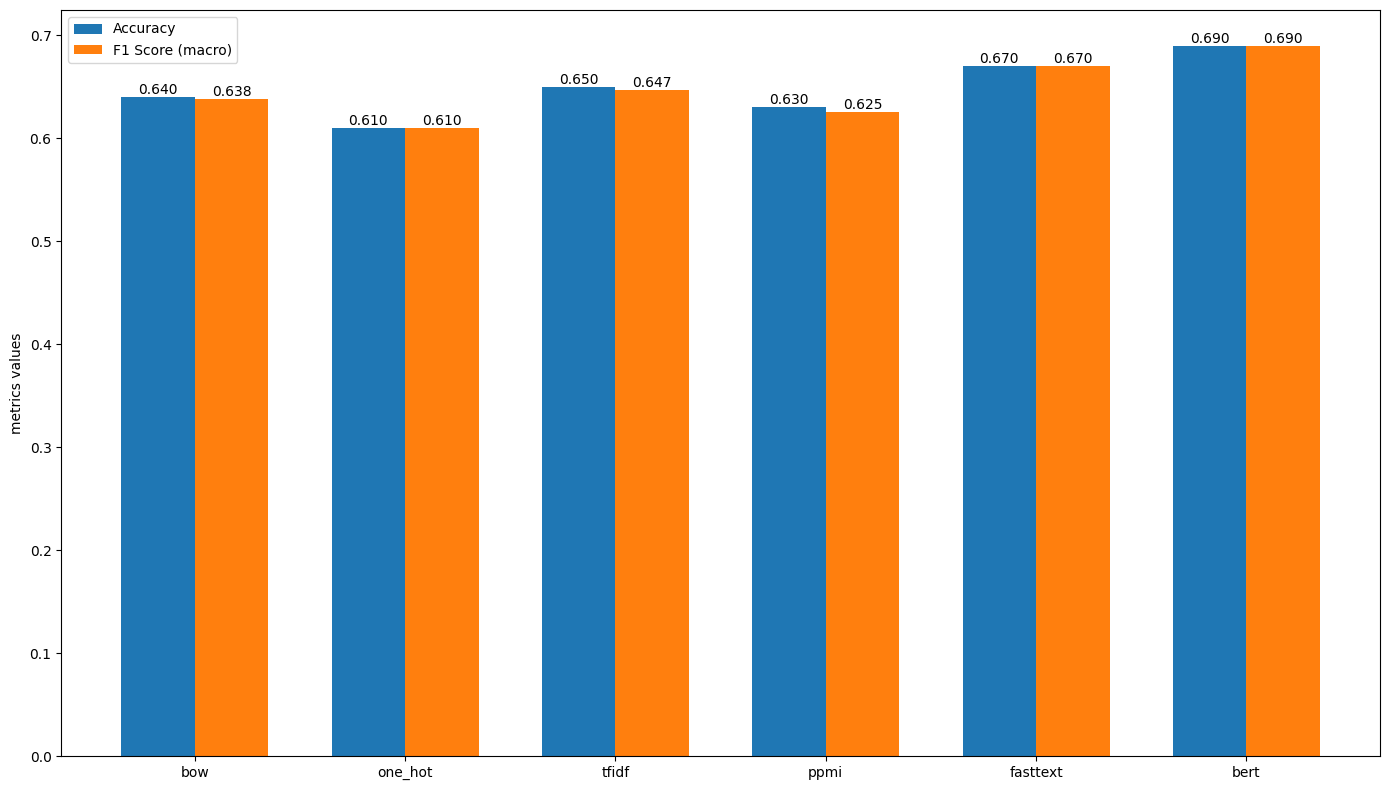

In [21]:
methods = [r[0] for r in results]
final_metrics = [r[1] for r in results]
final_accuracies = [m[0] for m in final_metrics]
final_f1_scores = [m[1] for m in final_metrics]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))
rects1 = ax.bar(x - width/2, final_accuracies, width, label='Accuracy')
rects2 = ax.bar(x + width/2, final_f1_scores, width, label='F1 Score (macro)')

ax.set_ylabel('metrics values')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()

ax.bar_label(rects1, fmt='%.3f')
ax.bar_label(rects2, fmt='%.3f')

fig.tight_layout()
plt.show()


/tmp/ipykernel_80611/540529951.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(cv_data_to_plot, labels=cv_methods)


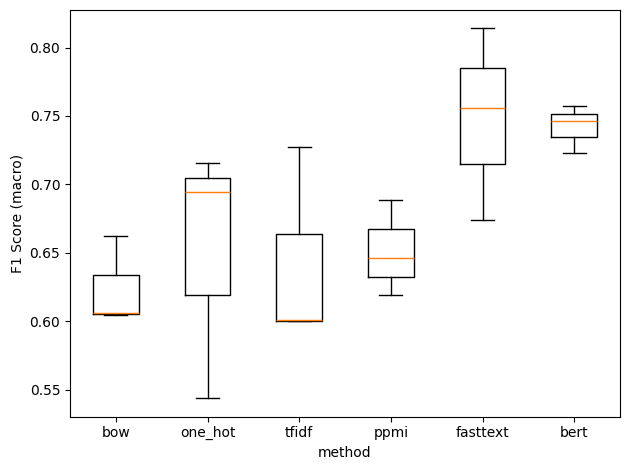

In [23]:

cv_results = [r[2] for r in results]
methods = [r[0] for r in results]

cv_data_to_plot = []
cv_methods = []
for i, scores in enumerate(cv_results):
    cv_data_to_plot.append(scores)
    cv_methods.append(methods[i])

if cv_data_to_plot:
    fig, ax = plt.subplots()
    ax.boxplot(cv_data_to_plot, labels=cv_methods)

    ax.set_ylabel('F1 Score (macro)')
    ax.set_xlabel('method')
    ax.set_xticklabels(cv_methods)

    plt.tight_layout()
    plt.show()